# FILE 2: FEDERATED LEARNING
## mALBERT (multilingual ALBERT, 32k vocab) - 5 Clients - 10 Rounds - **Flower + FedProx**
### Requires: results.json from File 1 uploaded as Kaggle dataset (optional, for centralized comparison)

**Total time: ~2.5-3.5 hours on T4 x2** (Flower simulation adds Ray overhead vs. the raw-PyTorch
loop used in the BanglishBERT/FedAvg notebook; budget slightly more time.)

**Model substitution note:** Google never released an official multilingual ALBERT. The 'cservan/malbert-base-*' family is the peer-reviewed, published multilingual ALBERT (mALBERT paper, 2024) and is the standard substitute used in the literature. Three vocab sizes exist (32k/64k/128k); 32k is used here for speed/memory. Swap FED_MODEL_NAME to the 64k or 128k variant if you want a larger vocabulary.

**Algorithm change from File 2 (BanglishBERT):** this notebook uses the [Flower](https://flower.ai)
federated learning framework with the **FedProx** strategy instead of a hand-rolled FedAvg loop.
FedProx adds a proximal term `(mu/2)*||w_local - w_global||^2` to each client's local loss, which
regularizes local updates toward the global model -- this generally improves stability when client
data is heterogeneous (exactly the case here: 5 clients, each holding a *different task*, i.e.
extreme non-IID data).

**After disconnect:** Run Cell 1 + Cell 2 + Cell 3, then continue from last saved round (Cell 5
auto-detects the last checkpoint and resumes the remaining rounds only).


## Cell 1: COMPLETE SETUP (install Flower, imports, model, Flower client) — Run after any disconnect

In [1]:
# ============================================================
# DEPENDENCIES — Flower + FedProx requires packages NOT preinstalled on Kaggle.
# We deliberately do NOT hard-pin ray's version: PyPI periodically yanks old
# ray releases (e.g. 2.9.3 has disappeared), which breaks a hard pin outright.
# Instead we pin flwr to a modern release and let pip resolve a ray version
# that flwr itself declares as compatible.
# ============================================================
import subprocess, sys

def pip_install(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir"] + pkgs,
                    check=True)

try:
    pip_install(["flwr[simulation]>=1.8.0,<2.0"])
except subprocess.CalledProcessError:
    print("Pinned flwr[simulation] range failed to resolve -- falling back to latest flwr 1.x")
    pip_install(["-U", "flwr[simulation]"])

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, copy, time, os, warnings
warnings.filterwarnings('ignore')
os.environ['RAY_DEDUP_LOGS'] = '0'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score,
    precision_score, recall_score,
    matthews_corrcoef, confusion_matrix
)
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader

import flwr as fl
from flwr.common import ndarrays_to_parameters, parameters_to_ndarrays

CKPT_DIR = '/kaggle/working/fed_checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)
DEVICE          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_GPUS_TOTAL  = torch.cuda.device_count()
USE_MULTI_GPU   = NUM_GPUS_TOTAL > 1   # now means "Flower can run 2 clients concurrently"

FED_MODEL_NAME = 'cservan/malbert-base-cased-32k'
MODEL_KEY      = 'ALBERT_multilingual'          # used for results.json lookups / output filenames
FED_ROUNDS     = 20
LOCAL_EPOCHS   = 1
FED_BATCH      = 32
FED_LR         = 2e-5
FEDPROX_MU     = 0.1           # proximal term strength; 0.0 reduces FedProx to FedAvg

class DeceptionDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts  = df['text'].fillna('').tolist()
        self.labels = df['is_deceptive'].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

class AttentionDeceptionClassifier(nn.Module):
    def __init__(self, model_name, dropout=0.4):
        super().__init__()
        # Some Hub checkpoints (e.g. the MiniLM/XLM-R distilled ones) ship weights
        # in fp16. Force float32 so the encoder's output dtype always matches the
        # float32 classifier head -- otherwise you get
        # "mat1 and mat2 must have the same dtype, but got Half and Float".
        self.encoder = AutoModel.from_pretrained(model_name, torch_dtype=torch.float32)
        self.encoder = self.encoder.float()
        h = self.encoder.config.hidden_size
        self.attention_pool = nn.Sequential(nn.Linear(h,256), nn.Tanh(), nn.Linear(256,1))
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(h,256), nn.GELU(),
            nn.Dropout(dropout/2), nn.Linear(256,2)
        )
    def forward(self, input_ids, attention_mask):
        out    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        hidden = out.last_hidden_state
        scores = self.attention_pool(hidden)
        scores = scores.masked_fill(attention_mask.unsqueeze(-1)==0, -1e9)
        pooled = (hidden * torch.softmax(scores, dim=1)).sum(dim=1)
        return self.classifier(pooled)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbls = batch['label'].to(device)
            logits = model(ids, mask)
            loss   = criterion(logits, lbls)
            probs  = torch.softmax(logits, dim=1)[:,1]
            preds  = logits.argmax(dim=1)
            total_loss += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return {
        'loss':      total_loss / len(loader),
        'acc':       accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='macro', zero_division=0),
        'recall':    recall_score(all_labels, all_preds, average='macro', zero_division=0),
        'f1':        f1_score(all_labels, all_preds, average='macro'),
        'f1_w':      f1_score(all_labels, all_preds, average='weighted'),
        'auc':       roc_auc_score(all_labels, all_probs),
        'mcc':       matthews_corrcoef(all_labels, all_preds),
        'preds':     all_preds,
        'labels':    all_labels,
    }

def get_parameters(model):
    return [val.cpu().numpy() for val in model.state_dict().values()]

def set_parameters(model, parameters):
    keys = list(model.state_dict().keys())
    state_dict = {k: torch.tensor(v) for k, v in zip(keys, parameters)}
    model.load_state_dict(state_dict, strict=True)

print('='*70)
print('FLOWER + FEDPROX SETUP COMPLETE')
print('='*70)
print(f'Device:        {DEVICE}')
print(f'GPUs visible:  {NUM_GPUS_TOTAL}  (Flower will run up to {max(NUM_GPUS_TOTAL,1)} clients concurrently)')
print(f'Checkpoint:    {CKPT_DIR}')
print(f'Model:         {FED_MODEL_NAME}')
print(f'Rounds:        {FED_ROUNDS}')
print(f'Local Epochs:  {LOCAL_EPOCHS}')
print(f'LR:            {FED_LR}')
print(f'FedProx mu:    {FEDPROX_MU}')
print()
print('IF NETWORK DISCONNECTED:')
print('  1. Re-run Cell 1 (this cell)')
print('  2. Re-run Cell 2 (load data)')
print('  3. Re-run Cell 3 (partition clients)')
print('  4. Re-run Cell 5 (Flower simulation) - it will auto-resume from the last checkpoint!')
print('='*70)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.5/974.5 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 167.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 292.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 392.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 303.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.5/310.5 kB 371.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 174.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 295.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.3/26.3 MB 229.4 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
grpcio-tools 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
black 26.5.1 requires pathspec>=1.0.0, but you have pathspec 0.12.1 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
bigframes 2.39.0 requires rich<14,>=12.4.4, 

FLOWER + FEDPROX SETUP COMPLETE
Device:        cuda
GPUs visible:  2  (Flower will run up to 2 clients concurrently)
Checkpoint:    /kaggle/working/fed_checkpoints
Model:         cservan/malbert-base-cased-32k
Rounds:        20
Local Epochs:  1
LR:            2e-05
FedProx mu:    0.1

IF NETWORK DISCONNECTED:
  1. Re-run Cell 1 (this cell)
  2. Re-run Cell 2 (load data)
  3. Re-run Cell 3 (partition clients)
  4. Re-run Cell 5 (Flower simulation) - it will auto-resume from the last checkpoint!


## Cell 2: Load Data + Week 1 Results

In [2]:
DATASET_NAME     = 'thesis-albert'   # <- update
RESULTS_DATASET  = 'week1-results'        # <- name you gave to results.json dataset

task_files = {
    'fake_news':            f'/kaggle/input/datasets/foysal2004042/thesis-albert/fake_news_sampled_multilingual.csv',
    'product_reviews':      f'/kaggle/input/datasets/foysal2004042/thesis-albert/product_reviews_sampled_multilingual.csv',
    'phishing':             f'/kaggle/input/datasets/foysal2004042/thesis-albert/phishing_sampled_multilingual.csv',
    'political_statements': f'/kaggle/input/datasets/foysal2004042/thesis-albert/political_statements_sampled_multilingual.csv',
    'job_scams':            f'/kaggle/input/datasets/foysal2004042/thesis-albert/job_scams_sampled_multilingual.csv',
}

dfs = []
for task, path in task_files.items():
    try:
        df = pd.read_csv(path)
        df['task'] = task
        dfs.append(df)
        print(f'  ok {task:<25} {len(df):>6,} rows')
    except FileNotFoundError:
        print(f'  FAIL {task} not found')

df_all   = pd.concat(dfs, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
train_df, temp_df = train_test_split(df_all, test_size=0.30, random_state=42, stratify=df_all['is_deceptive'])
val_df, test_df   = train_test_split(temp_df, test_size=0.6667, random_state=42, stratify=temp_df['is_deceptive'])

# Load Week 1 baseline. Looks for a key matching THIS notebook's model first
# (e.g. results.json['ALBERT_multilingual']); falls back to BanglishBERT's number
# (from the original centralized run) purely as a rough reference point, and
# finally to 0.0 if nothing is found. Only a same-model centralized run is a
# fair comparison -- treat the fallback numbers as context, not ground truth.
try:
    with open(f'/kaggle/input/{RESULTS_DATASET}/results.json') as f:
        week1_results = json.load(f)
    if MODEL_KEY in week1_results:
        CENTRALIZED_F1  = week1_results[MODEL_KEY]['macro_f1']
        CENTRALIZED_ACC = week1_results[MODEL_KEY]['accuracy']
        print(f'\nWeek 1 {MODEL_KEY} (matching model) loaded:')
    elif 'BanglishBERT' in week1_results:
        CENTRALIZED_F1  = week1_results['BanglishBERT']['macro_f1']
        CENTRALIZED_ACC = week1_results['BanglishBERT']['accuracy']
        print(f'\nNo centralized {MODEL_KEY} baseline found -- falling back to')
        print(f'BanglishBERT centralized numbers as a rough reference ONLY')
        print(f'(different backbone, not a fair apples-to-apples comparison):')
    else:
        raise KeyError('no usable key in results.json')
    print(f'  Centralized F1:  {CENTRALIZED_F1:.4f}')
    print(f'  Centralized Acc: {CENTRALIZED_ACC:.4f}')
except Exception as e:
    print(f'\nresults.json not usable ({e})')
    print('Manually enter your centralized F1/Acc for this model below if you have them:')
    CENTRALIZED_F1  =0.8358133450377172  # <- REPLACE with your actual value
    CENTRALIZED_ACC = 0.8358323721645521   # <- REPLACE with your actual value
    print('Replace 0.0 with your actual values!')

print(f'\nTrain: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
print('Data ready')


  ok fake_news                  6,496 rows
  ok product_reviews            2,238 rows
  ok phishing                   1,654 rows
  ok political_statements       1,394 rows
  ok job_scams                  1,216 rows

results.json not usable ([Errno 2] No such file or directory: '/kaggle/input/week1-results/results.json')
Manually enter your centralized F1/Acc for this model below if you have them:
Replace 0.0 with your actual values!

Train: 9,098 | Val: 1,299 | Test: 2,601
Data ready


## Cell 3: Divide into 5 Federated Clients

In [6]:
clients_data = {
    'Client_1_FakeNews':  train_df[train_df['task']=='fake_news'].reset_index(drop=True),
    'Client_2_Reviews':   train_df[train_df['task']=='product_reviews'].reset_index(drop=True),
    'Client_3_Phishing':  train_df[train_df['task']=='phishing'].reset_index(drop=True),
    'Client_4_Political': train_df[train_df['task']=='political_statements'].reset_index(drop=True),
    'Client_5_Scams':     train_df[train_df['task']=='job_scams'].reset_index(drop=True),
}
CLIENT_NAMES = list(clients_data.keys())
CLIENT_DFS   = list(clients_data.values())
NUM_CLIENTS  = len(CLIENT_NAMES)

total_samples = sum(len(d) for d in clients_data.values())

print('='*70)
print('5 FEDERATED CLIENTS (extreme non-IID: 1 task per client -- this is exactly')
print('the setting FedProx was designed to help with)')
print('='*70)
print(f'  {"Client":<30} {"Samples":>8}  {"FedAvg Weight":>14}')
print('  ' + '-'*55)
for name, df in clients_data.items():
    n = len(df)
    w = n / total_samples
    print(f'  {name:<30} {n:>8,}  {w:>14.4f}')
print('  ' + '-'*55)
print(f'  {"TOTAL":<30} {total_samples:>8,}  {1.0:>14.4f}')
print('='*70)


5 FEDERATED CLIENTS (extreme non-IID: 1 task per client -- this is exactly
the setting FedProx was designed to help with)
  Client                          Samples   FedAvg Weight
  -------------------------------------------------------
  Client_1_FakeNews                 4,533          0.4982
  Client_2_Reviews                  1,565          0.1720
  Client_3_Phishing                 1,161          0.1276
  Client_4_Political                  973          0.1069
  Client_5_Scams                      866          0.0952
  -------------------------------------------------------
  TOTAL                             9,098          1.0000


## Cell 4: Flower FedProx Client + Strategy (re-run after disconnect)

In [7]:
print('Loading shared tokenizer...')
fed_tokenizer = AutoTokenizer.from_pretrained(FED_MODEL_NAME)

fed_val_loader  = DataLoader(DeceptionDataset(val_df,  fed_tokenizer), batch_size=FED_BATCH*2, shuffle=False, num_workers=2)
fed_test_loader = DataLoader(DeceptionDataset(test_df, fed_tokenizer), batch_size=FED_BATCH*2, shuffle=False, num_workers=2)
fed_criterion   = nn.CrossEntropyLoss()

# ------------------------------------------------------------------
# Flower NumPyClient: does local training with the FedProx proximal term
# ------------------------------------------------------------------
class FlowerClient(fl.client.NumPyClient):
    def __init__(self, cid, client_df, model_name, tokenizer, device):
        self.cid        = cid
        self.client_df  = client_df
        self.model_name = model_name
        self.tokenizer  = tokenizer
        self.device     = device
        self.model      = AttentionDeceptionClassifier(model_name, dropout=0.4).to(device)

    def get_parameters(self, config):
        return get_parameters(self.model)

    def fit(self, parameters, config):
        set_parameters(self.model, parameters)
        # Snapshot of the GLOBAL weights at the start of this round, kept on-device,
        # used only for the FedProx proximal penalty (never updated during local steps).
        global_params = [torch.tensor(p, device=self.device) for p in parameters]

        mu           = float(config.get('proximal_mu', FEDPROX_MU))
        local_epochs = int(config.get('local_epochs', LOCAL_EPOCHS))
        client_name  = CLIENT_NAMES[int(self.cid)]

        loader    = DataLoader(DeceptionDataset(self.client_df, self.tokenizer),
                               batch_size=FED_BATCH, shuffle=True, num_workers=2)
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=FED_LR, weight_decay=0.02)
        criterion = nn.CrossEntropyLoss()
        self.model.train()
        t0 = time.time()

        for _ in range(local_epochs):
            for batch in loader:
                ids  = batch['input_ids'].to(self.device)
                mask = batch['attention_mask'].to(self.device)
                lbls = batch['label'].to(self.device)
                optimizer.zero_grad()
                logits = self.model(ids, mask)
                loss   = criterion(logits, lbls)

                if mu > 0:
                    prox_term = 0.0
                    for local_p, global_p in zip(self.model.parameters(), global_params):
                        prox_term = prox_term + torch.sum((local_p - global_p) ** 2)
                    loss = loss + (mu / 2.0) * prox_term

                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                optimizer.step()

        elapsed = time.time() - t0
        print(f'    {client_name:<30} {len(self.client_df):>5,} samples | mu={mu:.3f} | done in {elapsed:.0f}s')

        return get_parameters(self.model), len(self.client_df), {'client_name': client_name}

    def evaluate(self, parameters, config):
        # Federated (per-client) evaluation is disabled (fraction_evaluate=0.0 below);
        # global-model evaluation is done centrally on the server after aggregation
        # (see evaluate_fn), exactly like the original FedAvg notebook's Step 4.
        return 0.0, 1, {}


def client_fn(cid: str):
    idx = int(cid)
    client = FlowerClient(cid, CLIENT_DFS[idx], FED_MODEL_NAME, fed_tokenizer, DEVICE)
    return client.to_client()


# ------------------------------------------------------------------
# Server-side centralized evaluation function (runs on the driver process,
# not inside a Ray worker) -- mirrors "STEP 4: Evaluate" from the FedAvg notebook.
# ------------------------------------------------------------------
_eval_model = AttentionDeceptionClassifier(FED_MODEL_NAME, dropout=0.4).to(DEVICE)

def get_evaluate_fn():
    def evaluate_fn(server_round, parameters, config):
        set_parameters(_eval_model, parameters)
        m = evaluate(_eval_model, fed_val_loader, fed_criterion, DEVICE)
        return m['loss'], {
            'val_acc': m['acc'], 'val_precision': m['precision'], 'val_recall': m['recall'],
            'val_f1': m['f1'], 'val_auc': m['auc'], 'val_mcc': m['mcc'],
        }
    return evaluate_fn


def fit_config_fn(server_round: int):
    return {'proximal_mu': FEDPROX_MU, 'local_epochs': LOCAL_EPOCHS, 'server_round': server_round}


# ------------------------------------------------------------------
# AUTO-RESUME: figure out how many rounds are already done, and load the
# last saved global weights as this run's starting point.
# ------------------------------------------------------------------
fed_history_path = f'{CKPT_DIR}/federated_history.json'
if os.path.exists(fed_history_path):
    with open(fed_history_path) as f:
        federated_history = json.load(f)
    completed_rounds = len(federated_history)
    print(f'Resuming from round {completed_rounds + 1} (completed {completed_rounds} rounds)')
else:
    federated_history = []
    completed_rounds  = 0
    print('Starting fresh federated training')

init_model = AttentionDeceptionClassifier(FED_MODEL_NAME, dropout=0.4)
if completed_rounds > 0:
    last_ckpt = f'{CKPT_DIR}/global_model_round_{completed_rounds}.pt'
    init_model.load_state_dict(torch.load(last_ckpt, map_location='cpu'))
    print(f'Loaded checkpoint: {last_ckpt}')
else:
    print('Initialized fresh global model from pretrained weights')

initial_parameters = ndarrays_to_parameters(get_parameters(init_model))
del init_model

print('Flower client/strategy setup ready')


Loading shared tokenizer...


config.json:   0%|          | 0.00/809 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/693k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

...

AlbertModel LOAD REPORT from: cservan/malbert-base-cased-32k
Key                              | Status     |  | 
---------------------------------+------------+--+-
predictions.decoder.bias         | UNEXPECTED |  | 
predictions.dense.bias           | UNEXPECTED |  | 
predictions.dense.weight         | UNEXPECTED |  | 
sop_classifier.classifier.weight | UNEXPECTED |  | 
predictions.LayerNorm.bias       | UNEXPECTED |  | 
predictions.LayerNorm.weight     | UNEXPECTED |  | 
predictions.decoder.weight       | UNEXPECTED |  | 
sop_classifier.classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting fresh federated training


Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertModel LOAD REPORT from: cservan/malbert-base-cased-32k
Key                              | Status     |  | 
---------------------------------+------------+--+-
predictions.decoder.bias         | UNEXPECTED |  | 
predictions.dense.bias           | UNEXPECTED |  | 
predictions.dense.weight         | UNEXPECTED |  | 
sop_classifier.classifier.weight | UNEXPECTED |  | 
predictions.LayerNorm.bias       | UNEXPECTED |  | 
predictions.LayerNorm.weight     | UNEXPECTED |  | 
predictions.decoder.weight       | UNEXPECTED |  | 
sop_classifier.classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Initialized fresh global model from pretrained weights
Flower client/strategy setup ready


## Cell 5: Run Flower FedProx Simulation (Auto-Resume if Disconnected)

In [8]:
class CheckpointingFedProx(fl.server.strategy.FedProx):
    """FedProx strategy that also checkpoints the global model + round metrics
    to disk after every round, exactly like the manual FedAvg notebook did."""

    def __init__(self, *args, round_offset, fed_rounds_total, t_start, **kwargs):
        super().__init__(*args, **kwargs)
        self.round_offset     = round_offset      # rounds already completed before this run
        self.fed_rounds_total = fed_rounds_total
        self.t_start          = t_start
        self.t_round_start    = t_start

    def evaluate(self, server_round, parameters):
        self.t_round_start = self.t_round_start if server_round > 1 else self.t_start
        t_round0 = time.time()

        result = super().evaluate(server_round, parameters)
        if result is None:
            return result
        loss, metrics = result

        actual_round  = self.round_offset + server_round
        elapsed_round = time.time() - t_round0
        elapsed_total = time.time() - self.t_start

        print(f'\n  ROUND {actual_round}/{self.fed_rounds_total} RESULTS:')
        print(f'    Val Acc:       {metrics["val_acc"]:.4f}')
        print(f'    Val Precision: {metrics["val_precision"]:.4f}')
        print(f'    Val Recall:    {metrics["val_recall"]:.4f}')
        print(f'    Val F1:        {metrics["val_f1"]:.4f}  (Centralized: {CENTRALIZED_F1:.4f})')
        print(f'    Val AUC:       {metrics["val_auc"]:.4f}')
        print(f'    Val MCC:       {metrics["val_mcc"]:.4f}')
        print(f'    Round time:    {elapsed_round/60:.1f} min')
        print(f'    Total so far:  {elapsed_total/60:.1f} min')

        federated_history.append({
            'round': actual_round,
            'val_acc': metrics['val_acc'], 'val_precision': metrics['val_precision'],
            'val_recall': metrics['val_recall'], 'val_f1': metrics['val_f1'],
            'val_auc': metrics['val_auc'], 'val_mcc': metrics['val_mcc'],
            'time_min': elapsed_round / 60,
        })

        state_dict = {k: torch.tensor(v) for k, v in zip(_eval_model.state_dict().keys(),
                                                          parameters_to_ndarrays(parameters))}
        torch.save(state_dict, f'{CKPT_DIR}/global_model_round_{actual_round}.pt')
        with open(fed_history_path, 'w') as f:
            json.dump(federated_history, f, indent=2)
        print(f'    Checkpoint saved (round {actual_round})')
        print('-'*70)
        return result


remaining_rounds = FED_ROUNDS - completed_rounds

if remaining_rounds <= 0:
    print('All rounds already complete! Skip to Cell 6.')
else:
    print('='*70)
    print(f'FEDERATED LEARNING (Flower + FedProx) - ROUNDS {completed_rounds+1} to {FED_ROUNDS}')
    print('='*70)
    t_start = time.time()

    strategy = CheckpointingFedProx(
        fraction_fit=1.0,
        fraction_evaluate=0.0,          # centralized eval only (evaluate_fn below)
        min_fit_clients=NUM_CLIENTS,
        min_available_clients=NUM_CLIENTS,
        proximal_mu=FEDPROX_MU,
        on_fit_config_fn=fit_config_fn,
        evaluate_fn=get_evaluate_fn(),
        initial_parameters=initial_parameters,
        round_offset=completed_rounds,
        fed_rounds_total=FED_ROUNDS,
        t_start=t_start,
    )

    client_resources = {'num_cpus': 2, 'num_gpus': 1.0} if NUM_GPUS_TOTAL > 0 else {'num_cpus': 2}

    history = fl.simulation.start_simulation(
        client_fn=client_fn,
        num_clients=NUM_CLIENTS,
        config=fl.server.ServerConfig(num_rounds=remaining_rounds),
        strategy=strategy,
        client_resources=client_resources,
        ray_init_args={
            'num_cpus': max(8, NUM_CLIENTS * 2),
            'num_gpus': NUM_GPUS_TOTAL,
            'include_dashboard': False,
            'ignore_reinit_error': True,
        },
    )

    print(f'\nAll {FED_ROUNDS} rounds complete!')
    print(f'Total time: {(time.time()-t_start)/60:.1f} minutes')

# Rebuild the global_model object used by later cells from the final checkpoint
global_model = AttentionDeceptionClassifier(FED_MODEL_NAME, dropout=0.4)
with open(fed_history_path) as f:
    federated_history = json.load(f)
final_round = federated_history[-1]['round']
global_model.load_state_dict(torch.load(f'{CKPT_DIR}/global_model_round_{final_round}.pt', map_location='cpu'))
global_model = global_model.to(DEVICE)
print(f'global_model loaded from round {final_round} checkpoint for evaluation')


FEDERATED LEARNING (Flower + FedProx) - ROUNDS 1 to 20


	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Starting Flower simulation, config: num_rounds=20, no round_timeout
2026-07-04 18:16:13,848	INFO worker.py:2012 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprec


  ROUND 0/20 RESULTS:
    Val Acc:       0.4996
    Val Precision: 0.2498
    Val Recall:    0.5000
    Val F1:        0.3332  (Centralized: 0.8358)
    Val AUC:       0.4868
    Val MCC:       0.0000
    Round time:    0.2 min
    Total so far:  0.6 min
    Checkpoint saved (round 0)
----------------------------------------------------------------------


(ClientAppActor pid=337) <frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
(ClientAppActor pid=337) <frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
(ClientAppActor pid=336) <frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
(ClientAppActor pid=336) <frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
(ClientAppActor pid=337) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.app import Context`
(ClientAppActor pid=337) 
(ClientAppActor pid=337)             This is a deprecated feature. It will be removed
(ClientAppActor pid=337)             entirely in future versions of Flower.
(Clie

(ClientAppActor pid=336)     Client_5_Scams                   866 samples | mu=0.100 | done in 19s


...


  ROUND 20/20 RESULTS:
    Val Acc:       0.6952
    Val Precision: 0.7003
    Val Recall:    0.6951
    Val F1:        0.6931  (Centralized: 0.8358)
    Val AUC:       0.7711
    Val MCC:       0.3953
    Round time:    0.2 min
    Total so far:  49.0 min
    Checkpoint saved (round 20)
----------------------------------------------------------------------

All 20 rounds complete!
Total time: 49.0 minutes


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertModel LOAD REPORT from: cservan/malbert-base-cased-32k
Key                              | Status     |  | 
---------------------------------+------------+--+-
predictions.decoder.bias         | UNEXPECTED |  | 
predictions.dense.bias           | UNEXPECTED |  | 
predictions.dense.weight         | UNEXPECTED |  | 
sop_classifier.classifier.weight | UNEXPECTED |  | 
predictions.LayerNorm.bias       | UNEXPECTED |  | 
predictions.LayerNorm.weight     | UNEXPECTED |  | 
predictions.decoder.weight       | UNEXPECTED |  | 
sop_classifier.classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


global_model loaded from round 20 checkpoint for evaluation


## Cell 6: Final Test Evaluation

In [9]:
print('='*70)
print('FINAL TEST SET EVALUATION')
print('='*70)

test_m = evaluate(global_model, fed_test_loader, fed_criterion, DEVICE)

FED_FINAL_F1  = test_m['f1']
FED_FINAL_ACC = test_m['acc']

print(f'\nFederated Model ({FED_ROUNDS} rounds, FedProx mu={FEDPROX_MU}):')
print(f'  Accuracy:      {test_m["acc"]:.4f}')
print(f'  Precision:     {test_m["precision"]:.4f}')
print(f'  Recall:        {test_m["recall"]:.4f}')
print(f'  F1 (Macro):    {test_m["f1"]:.4f}  <- MAIN METRIC')
print(f'  F1 (Weighted): {test_m["f1_w"]:.4f}')
print(f'  AUC-ROC:       {test_m["auc"]:.4f}')
print(f'  MCC:           {test_m["mcc"]:.4f}')

print(f'\nCentralized Baseline ({MODEL_KEY} or fallback, see Cell 2):')
print(f'  F1 (Macro): {CENTRALIZED_F1:.4f}')

gap   = CENTRALIZED_F1 - FED_FINAL_F1 if CENTRALIZED_F1 else float('nan')
ratio = FED_FINAL_F1 / CENTRALIZED_F1 if CENTRALIZED_F1 else float('nan')
print(f'\nComparison:')
print(f'  F1 Gap:            {gap:.4f}')
print(f'  Accuracy Retained: {ratio:.1%}')
print('='*70)


FINAL TEST SET EVALUATION


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=58) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()



Federated Model (20 rounds, FedProx mu=0.1):
  Accuracy:      0.6943
  Precision:     0.6995
  Recall:        0.6944
  F1 (Macro):    0.6924  <- MAIN METRIC
  F1 (Weighted): 0.6924
  AUC-ROC:       0.7710
  MCC:           0.3939

Centralized Baseline (ALBERT_multilingual or fallback, see Cell 2):
  F1 (Macro): 0.8358

Comparison:
  F1 Gap:            0.1434
  Accuracy Retained: 82.8%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Cell 7: Generate All Thesis Figures

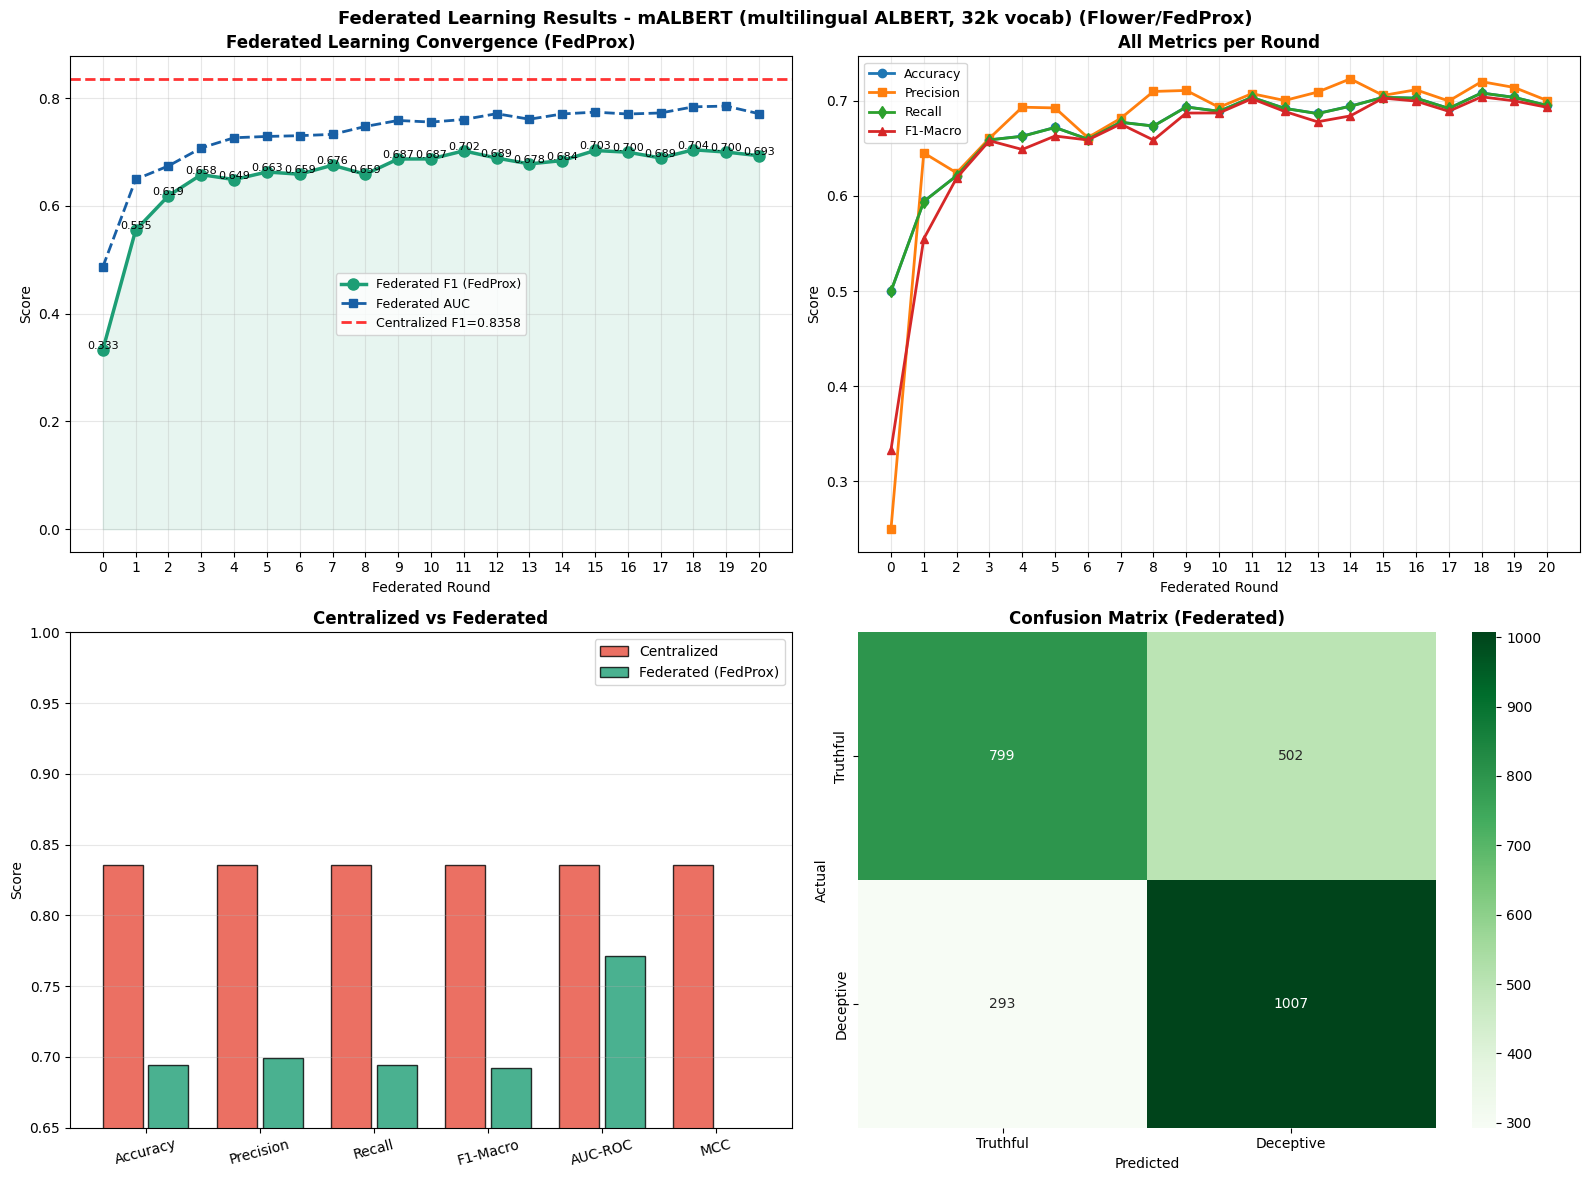

Saved: federated_results_figures_ALBERT_multilingual.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
with open(f'{CKPT_DIR}/federated_history.json') as f:
    federated_history = json.load(f)
df_hist = pd.DataFrame(federated_history)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Convergence curve
ax1 = axes[0, 0]
ax1.plot(df_hist['round'], df_hist['val_f1'], 'o-', color='#1D9E75', linewidth=2.5, markersize=8, label='Federated F1 (FedProx)')
ax1.plot(df_hist['round'], df_hist['val_auc'], 's--', color='#185FA5', linewidth=2, markersize=6, label='Federated AUC')
ax1.axhline(y=CENTRALIZED_F1, color='red', linestyle='--', linewidth=2, label=f'Centralized F1={CENTRALIZED_F1:.4f}', alpha=0.8)
ax1.fill_between(df_hist['round'], df_hist['val_f1'], alpha=0.1, color='#1D9E75')
ax1.set_xlabel('Federated Round')
ax1.set_ylabel('Score')
ax1.set_title('Federated Learning Convergence (FedProx)', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(df_hist['round'])
for x, y in zip(df_hist['round'], df_hist['val_f1']):
    ax1.text(x, y+0.002, f'{y:.3f}', ha='center', fontsize=8)

# Plot 2: All metrics over rounds
ax2 = axes[0, 1]
ax2.plot(df_hist['round'], df_hist['val_acc'],       'o-', linewidth=2, label='Accuracy')
ax2.plot(df_hist['round'], df_hist['val_precision'],  's-', linewidth=2, label='Precision')
ax2.plot(df_hist['round'], df_hist['val_recall'],     'd-', linewidth=2, label='Recall')
ax2.plot(df_hist['round'], df_hist['val_f1'],         '^-', linewidth=2, label='F1-Macro')
ax2.set_xlabel('Federated Round')
ax2.set_ylabel('Score')
ax2.set_title('All Metrics per Round', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(df_hist['round'])

# Plot 3: Centralized vs Federated bar
ax3 = axes[1, 0]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Macro', 'AUC-ROC', 'MCC']
fed_vals = [test_m['acc'], test_m['precision'], test_m['recall'], test_m['f1'], test_m['auc'], test_m['mcc']]
cen_vals = [CENTRALIZED_ACC, CENTRALIZED_ACC, CENTRALIZED_ACC, CENTRALIZED_F1, CENTRALIZED_F1, CENTRALIZED_F1]
x3 = range(len(metrics_names))
ax3.bar([i-0.2 for i in x3], cen_vals, 0.35, label='Centralized', color='#E74C3C', edgecolor='black', alpha=0.8)
ax3.bar([i+0.2 for i in x3], fed_vals, 0.35, label='Federated (FedProx)',   color='#1D9E75', edgecolor='black', alpha=0.8)
ax3.set_xticks(x3)
ax3.set_xticklabels(metrics_names, rotation=15)
ax3.set_ylabel('Score')
ax3.set_title('Centralized vs Federated', fontweight='bold')
ax3.legend()
ax3.set_ylim([0.65, 1.0])
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Confusion Matrix
ax4 = axes[1, 1]
cm = confusion_matrix(test_m['labels'], test_m['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax4,
            xticklabels=['Truthful','Deceptive'],
            yticklabels=['Truthful','Deceptive'])
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')
ax4.set_title('Confusion Matrix (Federated)', fontweight='bold')

plt.suptitle('Federated Learning Results - mALBERT (multilingual ALBERT, 32k vocab) (Flower/FedProx)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/federated_results_figures_ALBERT_multilingual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: federated_results_figures_ALBERT_multilingual.png')


## Cell 8: Save All Results

In [11]:
df_hist.to_csv('/kaggle/working/federated_rounds_history_ALBERT_multilingual.csv', index=False)

final = {
    'model': MODEL_KEY,
    'model_hf_checkpoint': FED_MODEL_NAME,
    'algorithm': 'FedProx',
    'fedprox_mu': FEDPROX_MU,
    'centralized_baseline': {'f1': CENTRALIZED_F1, 'accuracy': CENTRALIZED_ACC},
    'federated': {
        'rounds': FED_ROUNDS, 'local_epochs': LOCAL_EPOCHS,
        'clients': CLIENT_NAMES,
        'final_f1': FED_FINAL_F1, 'final_acc': FED_FINAL_ACC,
        'accuracy_retained': (FED_FINAL_F1 / CENTRALIZED_F1) if CENTRALIZED_F1 else None,
        'round_history': federated_history
    }
}
with open('/kaggle/working/federated_all_results_ALBERT_multilingual.json', 'w') as f:
    json.dump(final, f, indent=2)

print('\n' + '='*70)
print('ALL DONE - DOWNLOAD THESE FILES')
print('='*70)
print('  federated_results_figures_ALBERT_multilingual.png  <- ADD TO THESIS CHAPTER 5')
print('  federated_rounds_history_ALBERT_multilingual.csv   <- Round-by-round results')
print('  federated_all_results_ALBERT_multilingual.json     <- All numbers')
print()
print(f'  Model:              {MODEL_KEY}  ({FED_MODEL_NAME})')
print(f'  Algorithm:           FedProx (mu={FEDPROX_MU})')
print(f'  Centralized F1:     {CENTRALIZED_F1:.4f}')
print(f'  Federated F1:       {FED_FINAL_F1:.4f}')
print(f'  Accuracy Retained:  {(FED_FINAL_F1/CENTRALIZED_F1) if CENTRALIZED_F1 else float("nan"):.1%}')
print('='*70)



ALL DONE - DOWNLOAD THESE FILES
  federated_results_figures_ALBERT_multilingual.png  <- ADD TO THESIS CHAPTER 5
  federated_rounds_history_ALBERT_multilingual.csv   <- Round-by-round results
  federated_all_results_ALBERT_multilingual.json     <- All numbers

  Model:              ALBERT_multilingual  (cservan/malbert-base-cased-32k)
  Algorithm:           FedProx (mu=0.1)
  Centralized F1:     0.8358
  Federated F1:       0.6924
  Accuracy Retained:  82.8%
